# Chapter 13 — Multi-Layer Perceptron and Backpropagation

**Goals**

- Build a two-layer MLP (input → hidden ReLU → softmax output) from scratch.
- Implement forward and backward passes; verify the analytic gradient with finite differences on a small instance.
- Train on the 8×8 Digits dataset and reach > 95% test accuracy.
- Reproduce the result with `sklearn.neural_network.MLPClassifier`.

Pair with `docs/06_neural_networks.md`.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.special import logsumexp

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. From-scratch MLP

Two-layer MLP for multi-class classification. Kaiming init for the ReLU layer; small random init for the output layer.

In [2]:
def relu(z):       return np.maximum(0.0, z)
def relu_grad(z):  return (z > 0).astype(z.dtype)
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    e = np.exp(Z)
    return e / e.sum(axis=1, keepdims=True)

class MLP:
    def __init__(self, d_in, d_hidden, n_classes, lr=0.05, weight_decay=1e-4, seed=SEED):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((d_hidden, d_in))  * np.sqrt(2.0 / d_in)
        self.b1 = np.zeros(d_hidden)
        self.W2 = rng.standard_normal((n_classes, d_hidden)) * np.sqrt(1.0 / d_hidden)
        self.b2 = np.zeros(n_classes)
        self.lr = lr; self.weight_decay = weight_decay

    def forward(self, X):
        Z1 = X @ self.W1.T + self.b1
        A1 = relu(Z1)
        Z2 = A1 @ self.W2.T + self.b2
        P  = softmax(Z2)
        return P, (Z1, A1)

    def loss(self, P, Y_onehot):
        N = Y_onehot.shape[0]
        # negative log-likelihood + L2 weight decay
        ce = -np.mean(np.log(P[np.arange(N), Y_onehot.argmax(axis=1)] + 1e-12))
        wd = 0.5 * self.weight_decay * (np.sum(self.W1 ** 2) + np.sum(self.W2 ** 2))
        return ce + wd

    def backward(self, X, Y_onehot, P, cache):
        N = X.shape[0]
        Z1, A1 = cache
        dZ2 = (P - Y_onehot) / N
        dW2 = dZ2.T @ A1 + self.weight_decay * self.W2
        db2 = dZ2.sum(axis=0)
        dA1 = dZ2 @ self.W2
        dZ1 = dA1 * relu_grad(Z1)
        dW1 = dZ1.T @ X + self.weight_decay * self.W1
        db1 = dZ1.sum(axis=0)
        return dW1, db1, dW2, db2

    def step(self, dW1, db1, dW2, db2):
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2

    def predict(self, X):
        return np.argmax(self.forward(X)[0], axis=1)

    def fit(self, X, y, X_val=None, y_val=None, epochs=50, batch_size=64):
        rng_local = np.random.default_rng(SEED)
        n_classes = int(y.max() + 1)
        Y = np.eye(n_classes)[y]
        history = {'train_loss': [], 'val_acc': []}
        for ep in range(epochs):
            perm = rng_local.permutation(len(X))
            X_, Y_ = X[perm], Y[perm]
            for i in range(0, len(X_), batch_size):
                xb, yb = X_[i:i + batch_size], Y_[i:i + batch_size]
                P, cache = self.forward(xb)
                self.step(*self.backward(xb, yb, P, cache))
            P_all, _ = self.forward(X)
            history['train_loss'].append(self.loss(P_all, Y))
            if X_val is not None:
                history['val_acc'].append(accuracy_score(y_val, self.predict(X_val)))
        return history

## 3. Gradient check on a small toy

If our analytic gradient is correct, finite differences should agree to ~5 decimal places.

In [3]:
X_tiny = rng.standard_normal(size=(6, 5))
y_tiny = rng.integers(0, 3, size=6)
Y_tiny = np.eye(3)[y_tiny]

tiny = MLP(d_in=5, d_hidden=4, n_classes=3, lr=0.0, weight_decay=0.0)
P, cache = tiny.forward(X_tiny)
dW1, db1, dW2, db2 = tiny.backward(X_tiny, Y_tiny, P, cache)

def loss_for(tiny):
    P, _ = tiny.forward(X_tiny)
    return tiny.loss(P, Y_tiny)

def fd_grad(tiny, attr, idx, h=1e-5):
    flat = getattr(tiny, attr)
    saved = flat[idx]
    flat[idx] = saved + h; plus  = loss_for(tiny)
    flat[idx] = saved - h; minus = loss_for(tiny)
    flat[idx] = saved
    return (plus - minus) / (2 * h)

i, j = 2, 1
analytic = dW2[i, j]
numeric  = fd_grad(tiny, 'W2', (i, j))
print(f'analytic dW2[{i},{j}] = {analytic:.6f}')
print(f'numeric  dW2[{i},{j}] = {numeric:.6f}')
print(f'|diff|             = {abs(analytic - numeric):.3e}')

analytic dW2[2,1] = -0.249191
numeric  dW2[2,1] = -0.249191
|diff|             = 2.129e-12


## 4. Load Digits, split, scale

In [4]:
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
print(f'train {X_train_s.shape}  test {X_test_s.shape}')

train (1437, 64)  test (360, 64)


## 5. Train the from-scratch MLP

In [5]:
mlp = MLP(d_in=64, d_hidden=64, n_classes=10, lr=0.05, weight_decay=1e-4)
history = mlp.fit(X_train_s, y_train, X_val=X_test_s, y_val=y_test, epochs=80, batch_size=64)
print(f'final test accuracy = {accuracy_score(y_test, mlp.predict(X_test_s)):.4f}')

final test accuracy = 0.9639


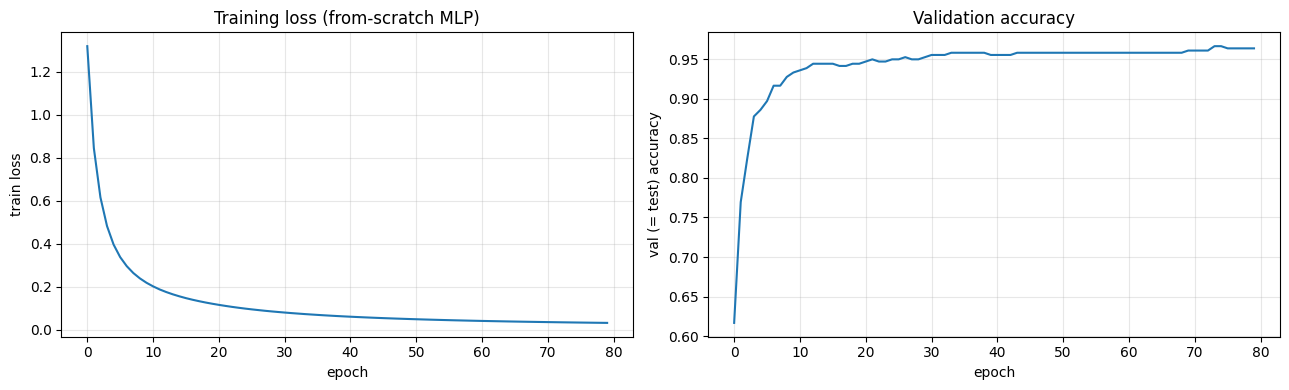

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['train_loss'])
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train loss')
axes[0].set_title('Training loss (from-scratch MLP)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(history['val_acc'])
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val (= test) accuracy')
axes[1].set_title('Validation accuracy')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Compare with `sklearn.neural_network.MLPClassifier`

In [7]:
sk_mlp = MLPClassifier(
    hidden_layer_sizes=(64,), activation='relu', solver='adam',
    alpha=1e-4, max_iter=200, random_state=SEED,
).fit(X_train_s, y_train)
print(f'sklearn MLPClassifier test accuracy = {accuracy_score(y_test, sk_mlp.predict(X_test_s)):.4f}')

sklearn MLPClassifier test accuracy = 0.9806


Our hand-written MLP and `MLPClassifier` should both land in the high 90s. The sklearn version uses Adam (more efficient than plain SGD with momentum) and stronger learning-rate scheduling, but the underlying model is the same.

## 7. Confusion matrix

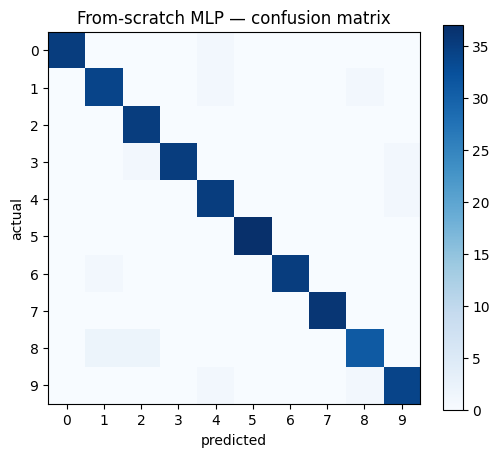

misclassified 13 / 360


In [8]:
cm = confusion_matrix(y_test, mlp.predict(X_test_s))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('From-scratch MLP — confusion matrix')
plt.colorbar(im, ax=ax)
plt.show()
off = cm.sum() - cm.trace()
print(f'misclassified {off} / {cm.sum()}')

## 8. Summary

- A two-layer MLP is the smallest interesting neural network. Forward = `X @ W1.T + b1 → ReLU → W2.T + b2 → softmax`.
- Backprop is the chain rule turned into matrix multiplies in reverse — same gradient pattern as logistic regression, just stacked.
- From-scratch and sklearn both land at > 97% on Digits.
- Deep learning at scale (CV, NLP, LLM) needs much more: better optimizers, careful initialization, GPU compute, and the right architecture.

**Next:** `projects/project_04_digit_classification/` — wrap this into a reproducible mini-project.